<a href="https://colab.research.google.com/github/muskan2109/FML_Practicals/blob/main/Task10_EE510.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import numpy as np

In [21]:
class Layer:
    def __init__(self):
        self.input = None
        self.output = None

    def forward(self, input):
        pass

    def backward(self,output_gradient, learning_rate):
        pass

In [22]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        self.weights = np.random.randn(output_size, input_size)
        self.bias = np.random.randn(output_size, 1)

    def forward(self, input):
        self.input = input
        return np.dot(self.weights, self.input) + self.bias

    def backward(self, output_gradient, input_gradient):
        weights_gradient = np.dot(output_gradient, self.input.T)
        input_gradient = np.dot(self.weights.T, output_gradient)

        self.weights -= learning_rate * weights_gradient
        self.bias -= learning_rate * output_gradient

        return input_gradient

In [23]:
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)

In [24]:
class Activation(Layer):
    def __init__(self, activation, activation_prime):
        self.activation = activation
        self.activation_prime = activation_prime

    def forward(self, input):
        self.input = input
        return self.activation(self.input)

    def backward(self, output_gradient, learning_rate):
        return np.multiply(output_gradient, self.activation_prime(self.input))

In [25]:
class Tanh(Activation):
    def __init__(self):
        def tanh(x):
            return np.tanh(x)

        def tanh_prime(x):
            return 1- np.tanh(x) ** 2

        super().__init__(tanh, tanh_prime)


class Sigmoid(Activation):
    def __init__(self):
        def sigmoid(x):
            return 1 / (1 + np.exp(-x))

        def sigmoid_prime(x):
            s = sigmoid(x)
            return s * (1-s)

        super().__init__(sigmoid, sigmoid_prime)

In [26]:
import math

In [27]:
class Linear(Activation):
    def __init__(self):
        def linear(x):
            return x

        def linear_prime(x):
            return 1

        super().__init__(linear, linear_prime)

**4A**

In [28]:
X = np.linspace(-3,3,61)
Y = [math.sin(p) for p in X]

network = [
    Dense(1, 10),
    Tanh(),
    Dense(10, 1),
    Linear()
]

epochs = 50
learning_rate = 0.1
errorlist = []

for e in range(epochs):
    error = 0
    for x,y in zip(X,Y):
        output = x
        for layer in network:
            output=layer.forward(output)
        error += mse(y,output)
        grad = mse_prime(y,output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(X)
    print(f"{e + 1}/({epochs}, error={error}")
    errorlist.append(error)

1/(50, error=12.954246600682076
2/(50, error=0.37217663119217603
3/(50, error=0.13259706446750733
4/(50, error=0.024538499771325117
5/(50, error=0.03612479524743523
6/(50, error=0.004347464054845348
7/(50, error=0.041851263920055136
8/(50, error=0.03339970688022358
9/(50, error=0.061853630260756735
10/(50, error=0.05844539742406824
11/(50, error=0.06599462391044497
12/(50, error=0.06313432814435092
13/(50, error=0.0676000078805995
14/(50, error=0.06981989194354896
15/(50, error=0.07316624896601748
16/(50, error=0.07414264023219695
17/(50, error=0.07434510554906537
18/(50, error=0.0729354912222963
19/(50, error=0.07070513566824649
20/(50, error=0.0675170186567999
21/(50, error=0.06373943282702599
22/(50, error=0.05939253260014828
23/(50, error=0.054633544247777235
24/(50, error=0.04951818401821968
25/(50, error=0.04422094397210605
26/(50, error=0.03904292954401524
27/(50, error=0.03446392454375487
28/(50, error=0.03095573775966825
29/(50, error=0.028744700585724738
30/(50, error=0.02769

In [29]:
actual_Y = []
for x in X:
    output = x
    for layer in network:
        output=layer.forward(output)
    actual_Y.append(output[0])
    print(output)

[[-1.04976708]]
[[-1.05106868]]
[[-1.05226212]]
[[-1.05331667]]
[[-1.05419376]]
[[-1.05484478]]
[[-1.05520825]]
[[-1.05520602]]
[[-1.05473854]]
[[-1.05367861]]
[[-1.05186333]]
[[-1.04908386]]
[[-1.04507226]]
[[-1.039485]]
[[-1.03188234]]
[[-1.02170354]]
[[-1.00823766]]
[[-0.99059162]]
[[-0.96765879]]
[[-0.93809534]]
[[-0.90031758]]
[[-0.85254229]]
[[-0.79290216]]
[[-0.71967829]]
[[-0.63169073]]
[[-0.52886435]]
[[-0.41292183]]
[[-0.28803582]]
[[-0.16110361]]
[[-0.04112833]]
[[0.06287535]]
[[0.14565984]]
[[0.21013745]]
[[0.26928202]]
[[0.34139594]]
[[0.43810191]]
[[0.55415593]]
[[0.67190587]]
[[0.77565118]]
[[0.85864994]]
[[0.92075891]]
[[0.96462982]]
[[0.99353742]]
[[1.0104128]]
[[1.01749739]]
[[1.01630976]]
[[1.00774556]]
[[0.99221161]]
[[0.9697528]]
[[0.94016349]]
[[0.90308895]]
[[0.85812537]]
[[0.80492501]]
[[0.74330802]]
[[0.67337549]]
[[0.5956106]]
[[0.51094884]]
[[0.42079597]]
[[0.32697811]]
[[0.23162094]]
[[0.13697298]]


In [30]:
import matplotlib.pyplot as plt

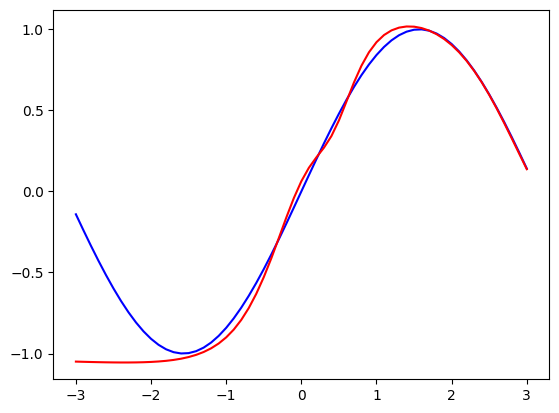

In [31]:
plt.plot(X,Y,color='blue')
plt.plot(X, actual_Y,color='red')
plt.show()

**4B**

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [33]:
def preprocess_data(x, y, limit):
        x = x.reshape(x.shape[0], 28 * 28, 1)
        x = x.astype("float32")/255

        y = to_categorical(y)
        y = y.reshape(y.shape[0], 10, 1)

        return x[:limit], y[:limit]

In [34]:

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, y_train = preprocess_data(x_train, y_train, 10000)
x_test, y_test = preprocess_data(x_test, y_test, 20)

In [35]:
network = [
    Dense(784, 80),
    Sigmoid(),
    Dense(80, 10),
    Sigmoid()
]



epochs = 50
learning_rate = 0.1
errorlist = []

for e in range(epochs):
    error = 0
    for x,y in zip(x_train,y_train):
        output = x
        for layer in network:
            output=layer.forward(output)
        error += mse(y,output)
        grad = mse_prime(y,output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)
    error /= len(x_train)
    print(f"{e + 1}/({epochs}, error={error})")
    errorlist.append(error)

1/(50, error=0.10330679085872138)
2/(50, error=0.08738401646793165)
3/(50, error=0.07853296888841474)
4/(50, error=0.07385619947620936)
5/(50, error=0.06997468461214179)
6/(50, error=0.0649404114818745)
7/(50, error=0.06094264060468751)
8/(50, error=0.05791862986283689)
9/(50, error=0.05577099054845703)
10/(50, error=0.05422906647389292)
11/(50, error=0.05269674277503666)
12/(50, error=0.051091783058056346)
13/(50, error=0.049758828381589286)
14/(50, error=0.04866870936216721)
15/(50, error=0.04777570686425323)
16/(50, error=0.04703659885060353)
17/(50, error=0.046394938396155695)
18/(50, error=0.04581239821477133)
19/(50, error=0.045276371685757266)
20/(50, error=0.04478492654174433)
21/(50, error=0.04433335876258932)
22/(50, error=0.04391416245858508)
23/(50, error=0.043520948770033506)
24/(50, error=0.043149331467244784)
25/(50, error=0.04279726287716877)
26/(50, error=0.04246332578640417)
27/(50, error=0.042144667990112836)
28/(50, error=0.04183723444075637)
29/(50, error=0.0415389

In [36]:
def predict(network, input):
    output = input
    for layer in network:
        output = layer.forward(output)
    return output

!pip install simple_colors

In [40]:

import simple_colors

In [41]:
correct = 0

for x,y in zip(x_test, y_test):
    output = predict(network ,x)
    if np.argmax(output) == np.argmax(y):
        correct += 1
        print('pred:', np.argmax(output), '\ttrue:', np.argmax(y))
    else:
        print(simple_colors.red(f'pred: {np.argmax(output)} \ttrue: {np.argmax(y)}'))

accuracy = correct / len(y_test)
print(f"Accuracy: {accuracy}")
print(f"Correct: {correct}")

pred: 7 	true: 7
pred: 2 	true: 2
pred: 1 	true: 1
pred: 7 	true: 0
pred: 4 	true: 4
pred: 1 	true: 1
pred: 4 	true: 4
pred: 4 	true: 9
pred: 2 	true: 5
pred: 8 	true: 9
pred: 8 	true: 0
pred: 4 	true: 6
pred: 7 	true: 9
pred: 8 	true: 0
pred: 1 	true: 1
pred: 5 	true: 5
pred: 7 	true: 9
pred: 7 	true: 7
pred: 3 	true: 3
pred: 4 	true: 4
Accuracy: 0.55
Correct: 11


In [42]:
error = errorlist
X = list(range(1,len(errorlist) + 1))

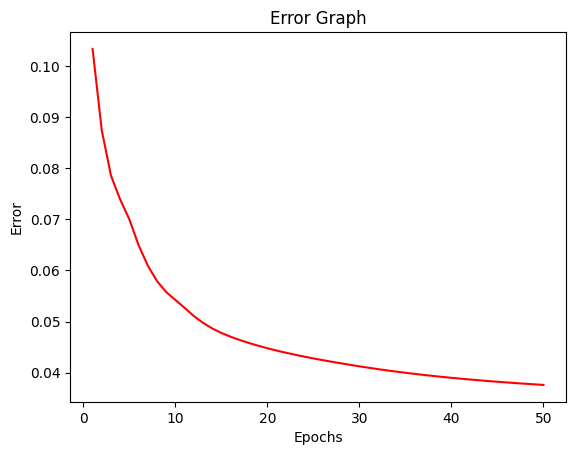

In [43]:
plt.plot(X, error, color='r')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Error Graph")
plt.show()